# RQ2 report plots

Nick Grebe i6377605

Plots for investigating RQ2 from the saved statistical outputs.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
from IPython.display import display

from Reporting.reporting_notebook_utils import (
    METRIC_LABEL_ORDER,
    configure_notebook,
    data_at_horizon,
    derive_rq2_columns,
    fraction_labels,
    load_rq2_outputs,
    save_figure,
    sorted_unique,
)

base_dir, figures_dir, plt = configure_notebook("rq2", font_size=11, display_width=160)


Base directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq2
Figures directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq2/figures


## Load and prepare RQ2 outputs

In [2]:
df, thresholds_df, pipeline_summaries = load_rq2_outputs(base_dir)
df = derive_rq2_columns(df)
split_order = sorted_unique(df["split"])
metric_order = [metric for metric in METRIC_LABEL_ORDER if metric in set(df["metric_label"])] or sorted_unique(df["metric_label"])

print("Derived columns:")
display(df[["split", "synthetic_size_fraction", "metric_label", "horizon_label", "relative_gap_pct", "equivalence_margin_pct"]].head())


Loaded 480 RQ2 result rows from 4 splits.
Loaded 24 threshold summary rows.
Derived columns:


,split,synthetic_size_fraction,metric_label,horizon_label,relative_gap_pct,equivalence_margin_pct
0,MOT20-01,0.05,ADE,0.6s,17.938139,5.0
1,MOT20-01,0.05,FDE,0.6s,18.132546,5.0
2,MOT20-01,0.10,ADE,0.6s,16.747584,5.0
3,MOT20-01,0.10,FDE,0.6s,16.907726,5.0
4,MOT20-01,0.15,ADE,0.6s,34.896293,5.0


## Relative gap vs synthetic fraction at 2.0s

Saved figures/rq2_relative_gap_2s.png


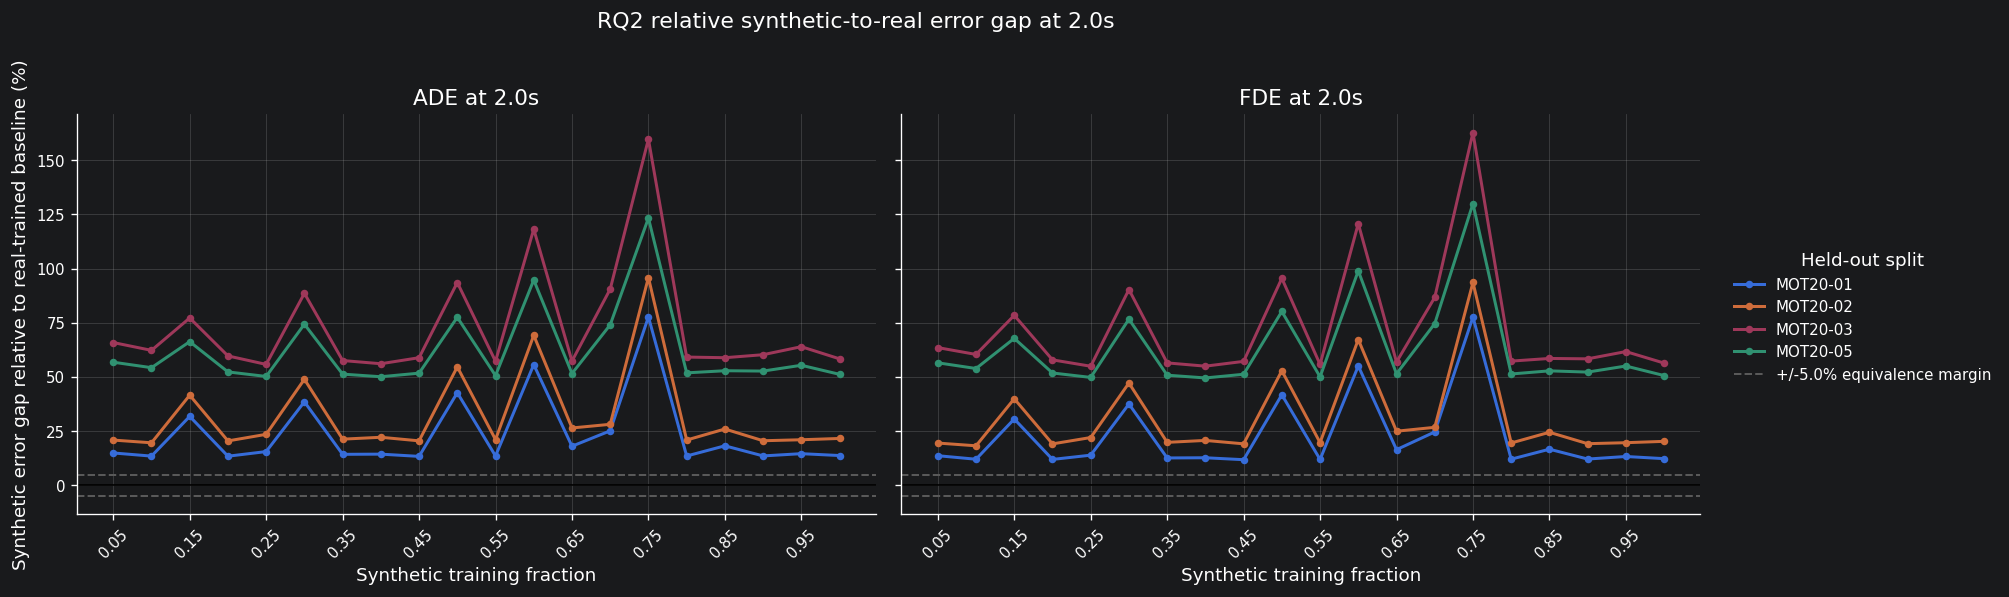

In [3]:
plot_df = data_at_horizon(df, 2.0)
fig, axes = plt.subplots(1, len(metric_order), figsize=(7.2 * len(metric_order), 4.8), sharey=True)
axes = [axes] if len(metric_order) == 1 else axes

for ax, metric_label in zip(axes, metric_order):
    metric_df = plot_df[plot_df["metric_label"] == metric_label].sort_values("synthetic_size_fraction")
    for split in split_order:
        split_df = metric_df[metric_df["split"] == split].sort_values("synthetic_size_fraction")
        ax.plot(split_df["synthetic_size_fraction"], split_df["relative_gap_pct"], marker="o", linewidth=1.8, markersize=3.5, label=split)

    margin_pct = metric_df["equivalence_margin_pct"].mean()
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(margin_pct, color="0.35", linewidth=1.2, linestyle="--", label=f"+/-{margin_pct:.1f}% equivalence margin")
    ax.axhline(-margin_pct, color="0.35", linewidth=1.2, linestyle="--")
    ax.set(title=f"{metric_label} at 2.0s", xlabel="Synthetic training fraction")
    ax.set_xticks(sorted_unique(metric_df["synthetic_size_fraction"])[::2])
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Synthetic error gap relative to real-trained baseline (%)")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Held-out split", loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("RQ2 relative synthetic-to-real error gap at 2.0s", y=1.03)
fig.tight_layout()
save_figure(fig, figures_dir, base_dir, "rq2_relative_gap_2s")
plt.show()


## Raw ADE/FDE curves at 2.0s

Saved figures/rq2_raw_error_2s_ADE.png


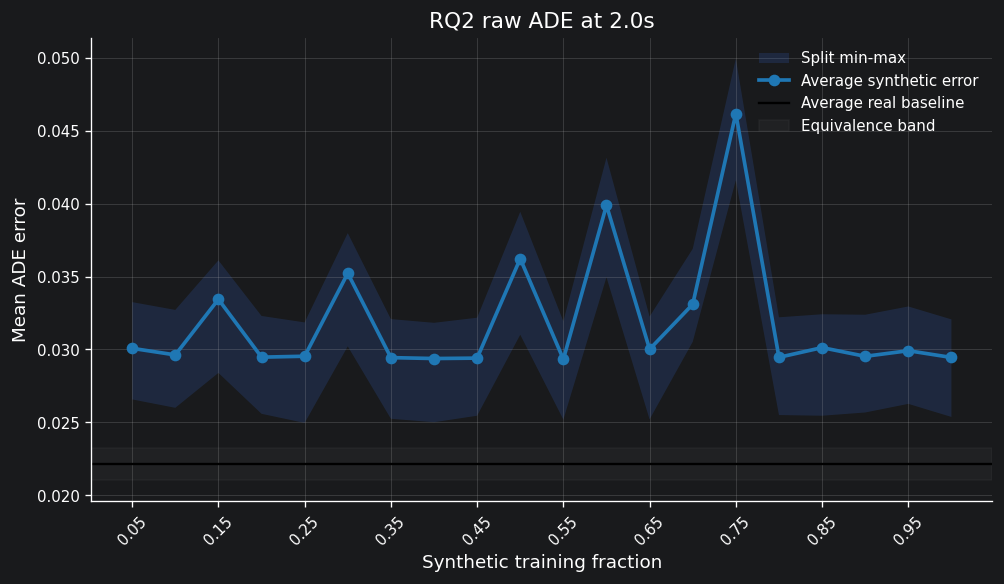

Saved figures/rq2_raw_error_2s_FDE.png


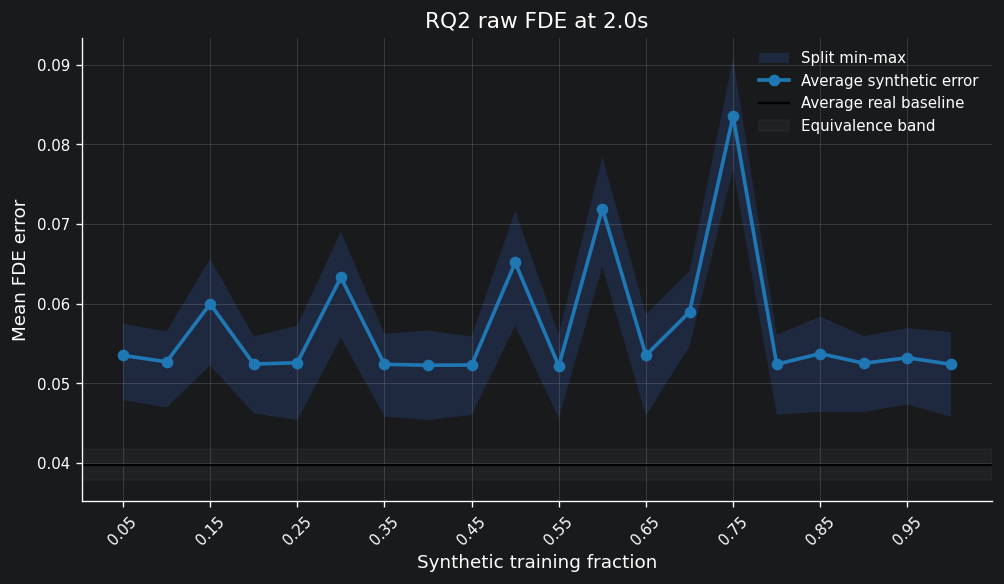

In [4]:
for metric_label in metric_order:
    metric_df = plot_df[plot_df["metric_label"] == metric_label].copy()
    synthetic_summary = metric_df.groupby("synthetic_size_fraction", as_index=False).agg(
        mean_synthetic_error=("mean_synthetic_error", "mean"),
        min_synthetic_error=("mean_synthetic_error", "min"),
        max_synthetic_error=("mean_synthetic_error", "max"),
    ).sort_values("synthetic_size_fraction")
    baseline_rows = metric_df.drop_duplicates(["split", "metric_label", "actual_horizon_s"])
    real_baseline = baseline_rows["mean_real_error"].mean()
    margin = baseline_rows["equivalence_margin"].mean()

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    x = synthetic_summary["synthetic_size_fraction"].to_numpy(dtype=float)
    y = synthetic_summary["mean_synthetic_error"].to_numpy(dtype=float)
    ax.fill_between(x, synthetic_summary["min_synthetic_error"], synthetic_summary["max_synthetic_error"], alpha=0.18, label="Split min-max")
    ax.plot(x, y, marker="o", color="#1f77b4", linewidth=2.2, label="Average synthetic error")
    ax.axhline(real_baseline, color="black", linewidth=1.4, label="Average real baseline")
    ax.axhspan(real_baseline - margin, real_baseline + margin, color="0.35", alpha=0.12, label="Equivalence band")
    ax.set(title=f"RQ2 raw {metric_label} at 2.0s", xlabel="Synthetic training fraction", ylabel=f"Mean {metric_label} error")
    ax.set_xticks(x[::2])
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, figures_dir, base_dir, f"rq2_raw_error_2s_{metric_label}")
    plt.show()


## Heatmap of mean relative gap across all horizons and metrics

Saved figures/rq2_relative_gap_heatmap.png


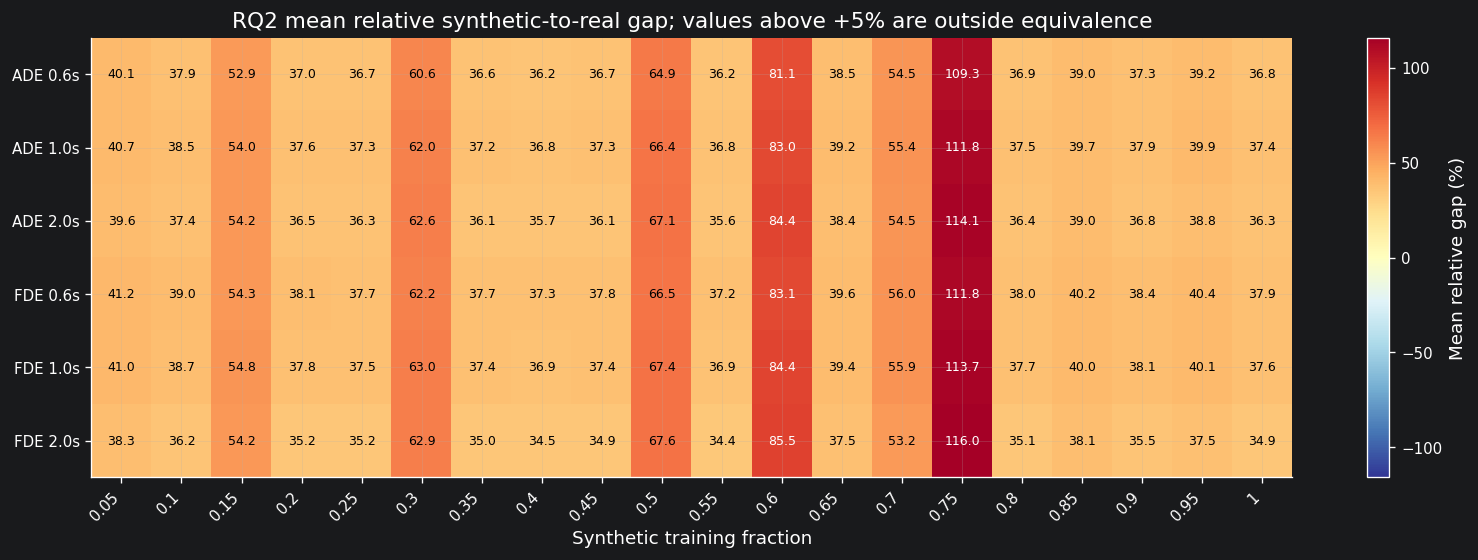

In [5]:
heatmap_df = df.copy()
heatmap_df["row_label"] = heatmap_df["metric_label"] + " " + heatmap_df["horizon_label"]
row_order = [f"{metric} {horizon:.1f}s" for metric in metric_order for horizon in sorted_unique(heatmap_df.loc[heatmap_df["metric_label"] == metric, "actual_horizon_s"])]
pivot = heatmap_df.groupby(["row_label", "synthetic_size_fraction"], as_index=False)["relative_gap_pct"].mean().pivot(
    index="row_label", columns="synthetic_size_fraction", values="relative_gap_pct"
).reindex(row_order)
pivot = pivot[sorted(pivot.columns)]
values = pivot.to_numpy(dtype=float)
vmax = np.nanmax(np.abs(values))

fig, ax = plt.subplots(figsize=(13.5, 4.8))
image = ax.imshow(values, aspect="auto", cmap="RdYlBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(pivot.shape[1]), fraction_labels(pivot.columns), rotation=45, ha="right")
ax.set_yticks(np.arange(pivot.shape[0]), pivot.index)
ax.set_xlabel("Synthetic training fraction")
ax.set_title("RQ2 mean relative synthetic-to-real gap; values above +5% are outside equivalence")

for row_idx in range(pivot.shape[0]):
    for col_idx in range(pivot.shape[1]):
        value = values[row_idx, col_idx]
        if np.isfinite(value):
            ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", fontsize=7.5, color="white" if abs(value) > 0.65 * vmax else "black")

fig.colorbar(image, ax=ax).set_label("Mean relative gap (%)")
fig.tight_layout()
save_figure(fig, figures_dir, base_dir, "rq2_relative_gap_heatmap")
plt.show()


## Minimum relative gap per synthetic fraction

Saved figures/rq2_best_observed_gap_by_fraction.png


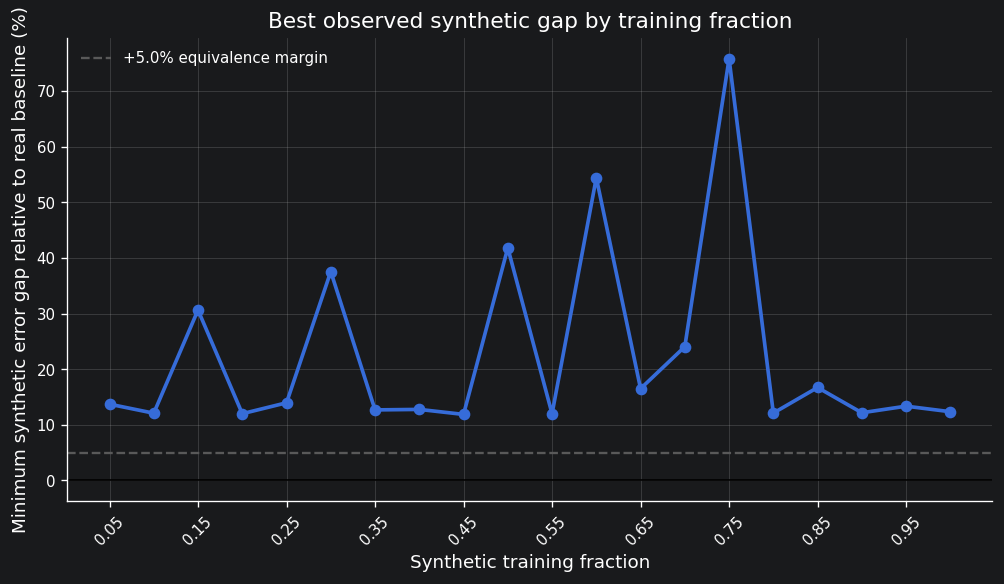

In [6]:
best_gap = df.groupby("synthetic_size_fraction", as_index=False)["relative_gap_pct"].min().sort_values("synthetic_size_fraction")
margin_pct = df["equivalence_margin_pct"].mean()

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(best_gap["synthetic_size_fraction"], best_gap["relative_gap_pct"], marker="o", linewidth=2.2)
ax.axhline(margin_pct, color="0.35", linestyle="--", linewidth=1.4, label=f"+{margin_pct:.1f}% equivalence margin")
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Best observed synthetic gap by training fraction", xlabel="Synthetic training fraction", ylabel="Minimum synthetic error gap relative to real baseline (%)")
ax.set_xticks(best_gap["synthetic_size_fraction"].iloc[::2])
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, figures_dir, base_dir, "rq2_best_observed_gap_by_fraction")
plt.show()
